In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

import matplotlib.pyplot as plt
from dataset import MOViC_Dataset
from torchvision import transforms
from torchvision.transforms import (
    RandomHorizontalFlip,
    RandomVerticalFlip,
    RandomRotation,
    ColorJitter,
    ToTensor,
    Resize
)
import numpy as np

import imageio
from io import BytesIO
from IPython.display import display, Image as IPImage
from PIL import Image

True


In [11]:
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'

### Test of dataset transformations

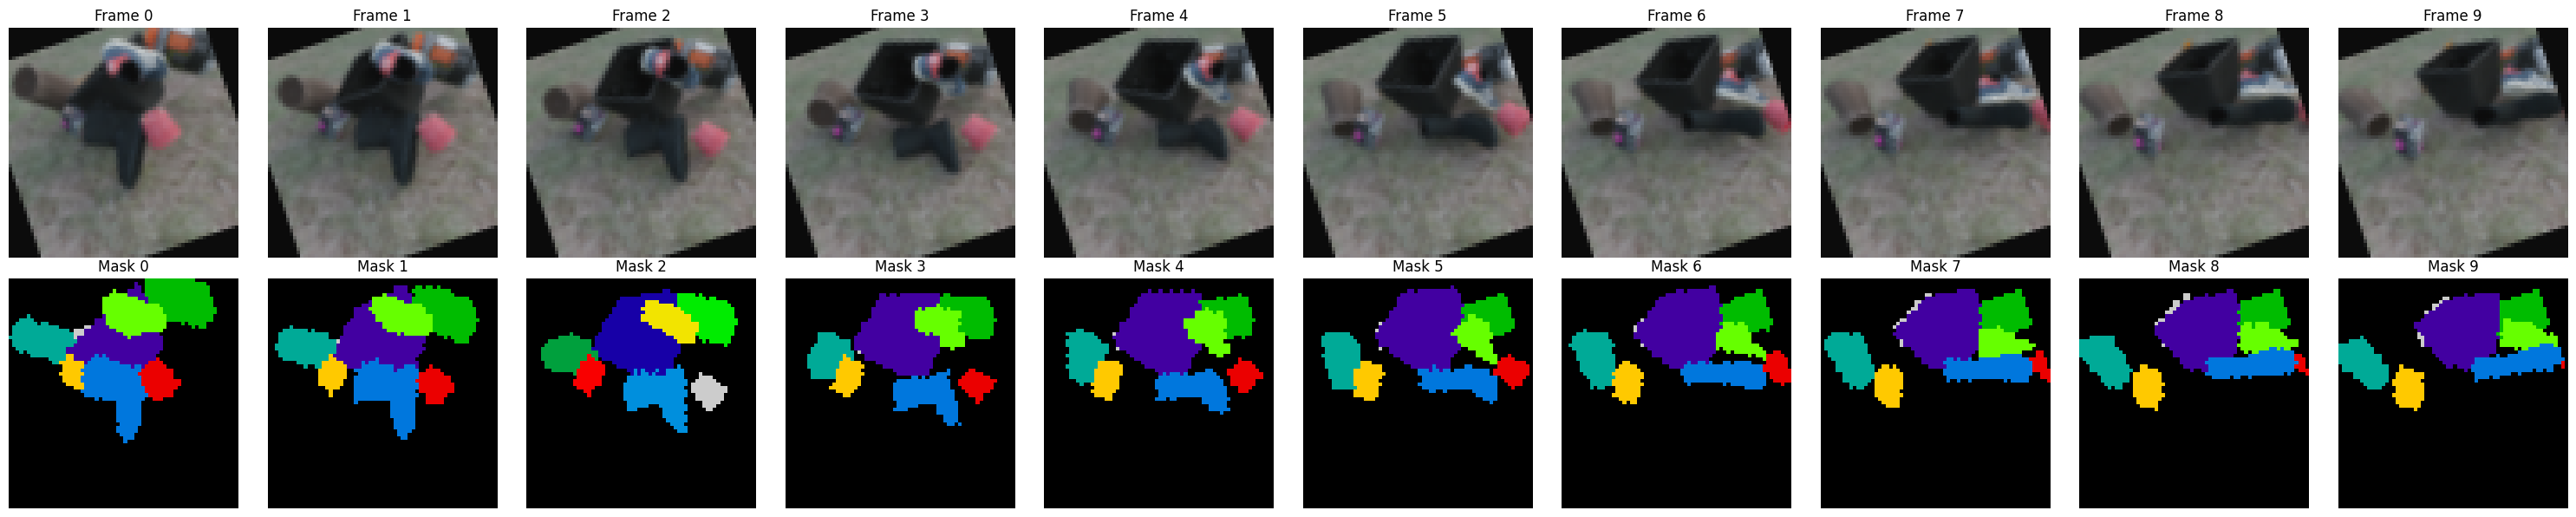

In [12]:
train_transform = transforms.Compose([
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=(-30, 30)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    )
])
dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="objects", img_size=(64, 64), transform=train_transform)
sample = dataset[2]

def show_frames_and_masks(sample, n=5, cmap="tab20"):
    """
    sample: [(frame, mask), ...]
    n: how many frames to show
    """
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    cmap = plt.get_cmap(cmap)

    for i, (frame, mask) in enumerate(sample[:n]):
        frame = frame.permute(1, 2, 0).numpy()  # CHW -> HWC
        mask = mask.squeeze().numpy().astype(int)

        axes[0, i].imshow(frame)
        axes[0, i].set_title(f"Frame {i}")
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap=cmap, interpolation="nearest")
        axes[1, i].set_title(f"Mask {i}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

show_frames_and_masks(sample, n=10, cmap="nipy_spectral")

In [13]:
def visualize_frames_as_gif(frames, fps: int = 5, scale: float = 1.0, width: int | None = None, height: int | None = None):
    images = []
    if isinstance(frames, torch.Tensor):
        if frames.ndim == 4 and frames.shape[1] in (1,3):
            frames = frames.permute(0,2,3,1).cpu().numpy()
        for f in frames:
            arr = (f * 255).clip(0,255).astype("uint8")
            img = Image.fromarray(arr)
            # масштаб
            w, h = img.size
            if width and height:
                img = img.resize((width, height), Image.NEAREST)
            elif scale != 1.0:
                img = img.resize((int(w*scale), int(h*scale)), Image.NEAREST)
            images.append(img)

    with BytesIO() as buffer:
        imageio.mimsave(buffer, images, format="GIF", duration=1/fps)
        buffer.seek(0)
        display(IPImage(data=buffer.getvalue()))

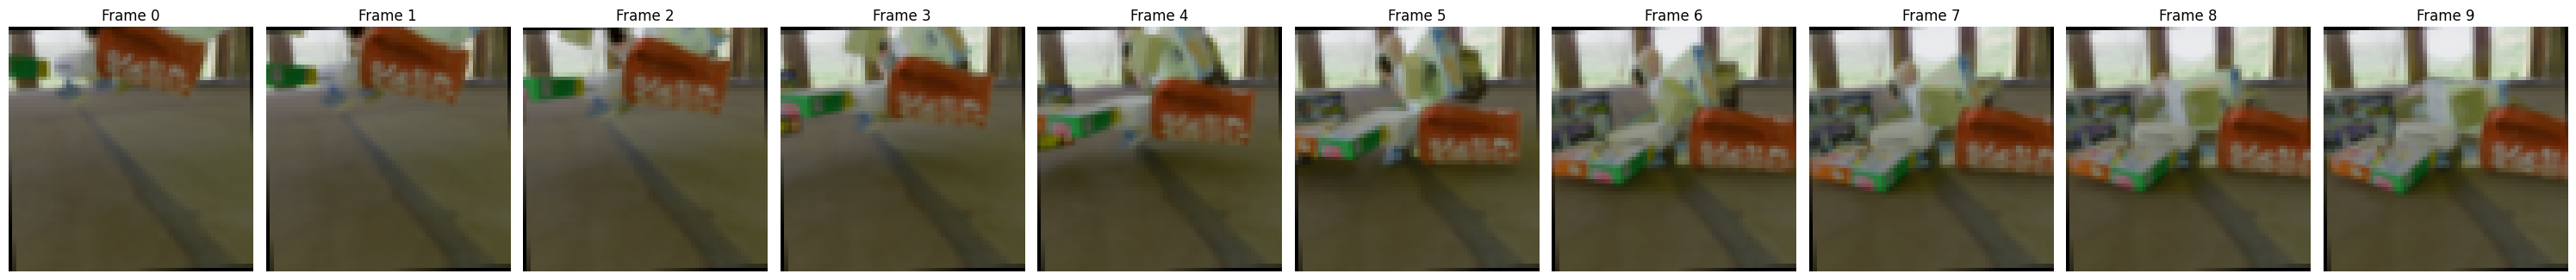

In [14]:
dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="rgb", img_size=(64, 64), transform=train_transform)
new_sample = dataset[5] # list [frame1, frame2, ...]

def show_frames_and_masks(sample, n=5, cmap="tab20"):
    """
    sample: [(frame, mask), ...]
    n: сколько кадров показать
    """
    fig, axes = plt.subplots(1, n, figsize=(3*n, 6))
    cmap = plt.get_cmap(cmap)

    for i, frame in enumerate(sample[:n]):
        frame = frame.permute(1, 2, 0).numpy()  # CHW -> HWC
        # верхняя строка: кадры
        axes[i].imshow(frame)
        axes[i].set_title(f"Frame {i}")
        axes[i].axis("off")
    

    plt.tight_layout()
    plt.show()

show_frames_and_masks(new_sample, n=10, cmap="nipy_spectral")

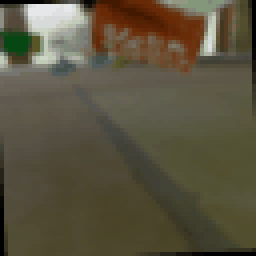

In [15]:
visualize_frames_as_gif(new_sample, fps=1, scale=4)

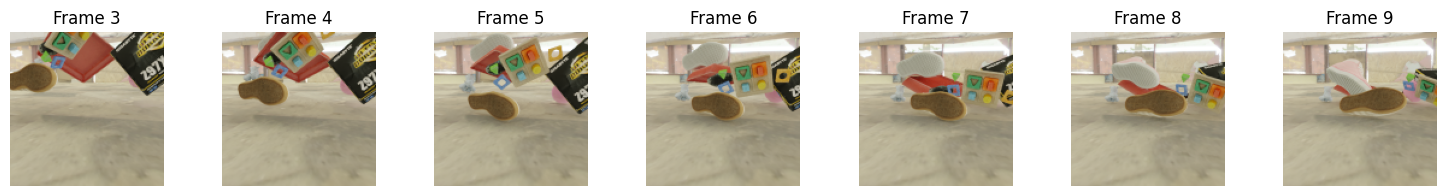

In [16]:
from utils.display_frame_sequence import display_frame_sequence

display_frame_sequence(f"{DATASET_PATH}/validation", video_id=144, num_frames=10, start_frame=3)

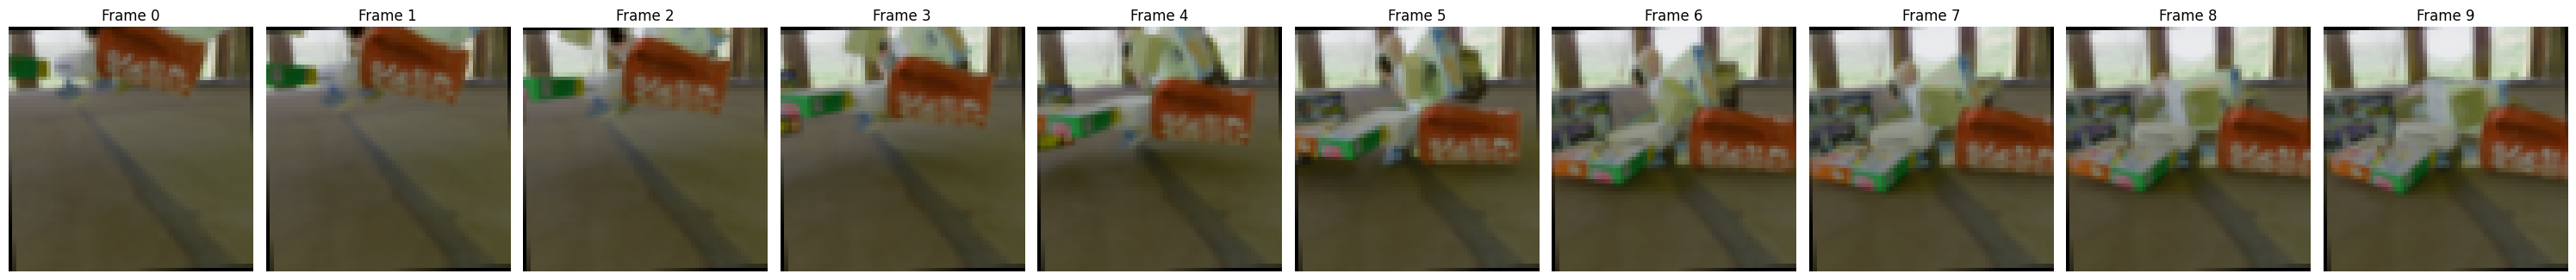

In [17]:
show_frames_and_masks(new_sample.detach(), n=10, cmap="nipy_spectral")

### Transformer test

In [18]:
from save_load import load_model
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder

PATCH_SIZE = 8 #maybe bigger?
H, W = 64, 64
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=128,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=128,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

model_path = 'experiments_released/24-09-2025_10-28_Patch_AE/checkpoints'
encoder, _, _ = load_model(encoder, None, 'encoder', model_path)
decoder, _, _ = load_model(decoder, None, 'decoder', model_path)

In [19]:
from models.vpt import VideoFrameTransformer

transformer_model = VideoFrameTransformer(
    encoder=encoder,
    decoder=decoder,
    H=64, W=64,
    patch_size=PATCH_SIZE,
    embed_dim=128,
    attn_dim=16, #emb // num_of_heads!!!!!!!!!!!!!! 52
    num_heads=8,
    mlp_size=1024,
    num_tf_layers_ar=12
)

for name, param in transformer_model.named_parameters():
    print(name, param.shape, param.requires_grad)

encoder.patch_projection.0.weight torch.Size([192]) False
encoder.patch_projection.0.bias torch.Size([192]) False
encoder.patch_projection.1.weight torch.Size([128, 192]) False
encoder.patch_projection.1.bias torch.Size([128]) False
encoder.transformer_blocks.0.ln_att.weight torch.Size([128]) False
encoder.transformer_blocks.0.ln_att.bias torch.Size([128]) False
encoder.transformer_blocks.0.attn.q.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.attn.k.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.attn.v.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.attn.out_proj.weight torch.Size([128, 512]) False
encoder.transformer_blocks.0.ln_mlp.weight torch.Size([128]) False
encoder.transformer_blocks.0.ln_mlp.bias torch.Size([128]) False
encoder.transformer_blocks.0.mlp.mlp.0.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.mlp.mlp.0.bias torch.Size([512]) False
encoder.transformer_blocks.0.mlp.mlp.3.weight torch.Size([128, 51

In [20]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])


In [21]:
train_dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="rgb", img_size=(64, 64), transform=train_transform)
val_dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="validation", target="rgb", img_size=(64, 64), target_frames=15, transform=val_transform)

In [22]:
from torch.utils.data import DataLoader

B_SIZE = 2

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

frames shape: torch.Size([20, 3, 64, 64])


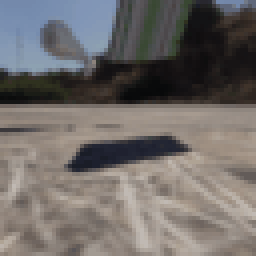

In [23]:
sample = val_dataset[0]   # обычно это (T, C, H, W) или (x, y)
if isinstance(sample, tuple):
    frames = sample[0]    # если датасет возвращает (video, target)
else:
    frames = sample       # если только видео

print("frames shape:", frames.shape)  # ожидаем (T, C, H, W)

# визуализируем как GIF
visualize_frames_as_gif(frames, fps=5, scale=4)

In [24]:
import lpips
import torch.nn as nn

class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=0.1, device="cuda"):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.lpips = lpips.LPIPS(net="alex").to(device)
        self.alpha = alpha
        self.beta = beta

    def forward(self, pred, target):
        """
        pred, target: (B, T, C, H, W)
        """
        # L1 loss по всему тензору
        loss_l1 = self.l1(pred, target)

        B, T, C, H, W = pred.shape
        loss_lpips = 0.0
        for t in range(T):
            # кадр t: (B, C, H, W)
            pred_frame = pred[:, t]
            target_frame = target[:, t]

            # LPIPS требует [-1,1]
            pred_norm = pred_frame * 2 - 1
            target_norm = target_frame * 2 - 1

            loss_lpips += self.lpips(pred_norm, target_norm).mean()

        loss_lpips = loss_lpips / T  # усреднение по времени

        return self.alpha * loss_l1 + self.beta * loss_lpips

In [25]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluate import evaluate_ar_transformer
from train_new import TrainerAutoRegressive, TrainerAR

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-4) #10-4
criterion = torch.nn.MSELoss()
#criterion = CombinedLoss(alpha=1.0, beta=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = TrainerAR(model=transformer_model, evaluate=evaluate_ar_transformer,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler, experiment_name="TransformerPredictorRGB")
trainer.train(train_loader, val_loader, 5, eval_freq=100)

Ep 0 Iter 0: Loss=0.03063):   0%|                                                                                                            | 0/5 [00:00<?, ?it/s]/home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


Ep 0 Iter 3: Loss=0.02252):   0%|                                                                                                            | 0/5 [00:47<?, ?it/s]

{'iter': 0, 'batch_size': 2, 'epoch': 0, 'loss': 0.030627954751253128, 'Loss': 0.19388834446668624, 'SSIM': 0.21472147522845408, 'PSNR': 13.509503856540915, 'LPIPS': 0.7400452798922856}


Ep 0 Iter 100: Loss=0.03364):   0%|                                                                                                          | 0/5 [00:53<?, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 24300, 'batch_size': 2, 'epoch': 4, 'loss': 0.016757600009441376, 'Loss': 0.15630858445167542, 'SSIM': 0.30459414571792526, 'PSNR': 14.851414677814697, 'LPIPS': 0.4494043684452772}


Ep 4 Iter 24341: Loss=0.01644):   0%|                                                                                                      | 0/5 [4:50:57<?, ?it/s]

Saved epoch_004_iter_24341's state to experiments/26-09-2025_11-50_TransformerPredictorRGB/checkpoints/epoch_004_iter_24341.pth


Ep 4 Iter 24344: Loss=0.00962):   0%|                                                                                                      | 0/5 [4:50:57<?, ?it/s]

Training completed
Saved epoch_005_iter_24345's state to experiments/26-09-2025_11-50_TransformerPredictorRGB/checkpoints/epoch_005_iter_24345.pth


## Обучение автоэнкодеров

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

True


In [3]:
from dataset import ImageDataset
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

dataset = ImageDataset(VALIDATION_PATH, train_transform)
sample = dataset[0]

(-0.5, 63.5, 63.5, -0.5)

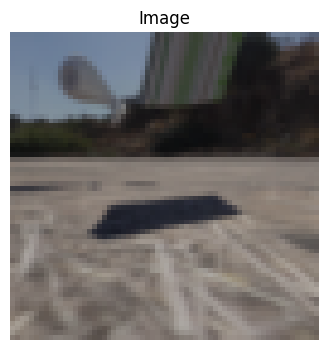

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.title("Image")
plt.axis("off")

In [5]:
train_dataset = ImageDataset(TRAIN_PATH, train_transform)
val_dataset = ImageDataset(VALIDATION_PATH, val_transform)

In [6]:
from torch.utils.data import DataLoader

B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [7]:
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder

PATCH_SIZE = 4
H, W = 64, 64
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=512,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=2048,
                          num_tf_layers=4)

decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=512,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=2048,
                          num_tf_layers=4)

autoencoder_img = ImageAutoencoder(encoder, decoder)

In [8]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluate import evaluate_autoencoder
from train import Trainer

optimizer = torch.optim.Adam(autoencoder_img.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler, experiment_name="TransformerPatch_AE")
trainer.train(train_loader, val_loader, 10)

Ep 0 Iter 1: Loss=10.66085):   0%|                                                                                               | 0/10 [00:14<?, ?it/s]

{'iter': 0, 'batch_size': 64, 'epoch': 0, 'loss': 1.249132513999939, 'Loss': 10.597419109750302, 'SSIM': 0.00899591801487491, 'PSNR': 8.94855463308299}


Ep 0 Iter 1000: Loss=0.02235):   0%|                                                                                             | 0/10 [02:21<?, ?it/s]

{'iter': 1000, 'batch_size': 64, 'epoch': 0, 'loss': 0.022351454943418503, 'Loss': 0.017637188615713346, 'SSIM': 0.5609307410465963, 'PSNR': 18.02917096816647}


Ep 0 Iter 2000: Loss=0.01686):   0%|                                                                                             | 0/10 [04:43<?, ?it/s]

...

{'iter': 36000, 'batch_size': 64, 'epoch': 9, 'loss': 0.005245408974587917, 'Loss': 0.004315114229610388, 'SSIM': 0.8796594416371724, 'PSNR': 24.770463551268826}


Ep 9 Iter 36511: Loss=0.00477):   0%|                                                                                          | 0/10 [1:26:38<?, ?it/s]

Saved epoch_009_iter_36511's state to experiments/19-09-2025_03-56_TransformerPatch_AE/checkpoints/epoch_009_iter_36511.pth


Ep 9 Iter 36519: Loss=0.00524):   0%|                                                                                          | 0/10 [1:26:39<?, ?it/s]

Training completed
Saved epoch_010_iter_36520's state to experiments/19-09-2025_03-56_TransformerPatch_AE/checkpoints/epoch_010_iter_36520.pth
